# PLS Regression

## What it does
Partial Least Squares (PLS) performs **simultaneous dimensionality reduction and regression**.
It finds latent components that maximise the *covariance* between X and y — unlike PCA, which ignores y entirely.

$$\hat{y} = \alpha + \sum_{k=1}^{K} \gamma_k \, T_k$$

where $T_k$ are PLS components derived from the original features.

## When to use it
- Many correlated predictors (multicollinearity)
- Number of features close to or exceeding number of observations (p ≈ n or p > n)
- You want a compact, interpretable summary of which feature groups drive the target

## Key hyperparameter
- **n_components** — number of latent components to extract. More = higher training fit but risk of overfitting. Selected here by validation OOS R².

## Comparison to Ridge/Lasso
PLS does not shrink individual coefficients. It reduces the feature space first and regresses on the reduced space. Works best when the signal is spread across many correlated features rather than concentrated in a few.

## Configuration

Edit the values below to adapt this notebook to a new dataset.

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        True,   # Recommended: PLS is sensitive to feature scale
    # --- PLS component grid ---
    'N_COMPONENTS_GRID':  [1, 2, 3, 5, 10, 15, 20],
    'MAX_ITER':           500,
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         'results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  STANDARDIZE: True
  N_COMPONENTS_GRID: [1, 2, 3, 5, 10, 15, 20]
  MAX_ITER: 500
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../../').resolve()))

from utils import (
    load_parquet, time_series_split, prepare_panel_data,
    standardize_splits, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df, CONFIG['DATE_COL'], CONFIG['TRAIN_YEARS'], CONFIG['VAL_YEARS']
)
print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']} — {split_info['val_end']}  ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']} — {split_info['test_end']}  ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945 — 1956  (709 obs)
Test       : 1957 — 2022  (77,548 obs)


## Step 2 — Prepare Features & Standardize

In [4]:
X, y, feature_cols = prepare_panel_data(
    df,
    target_col   = CONFIG['TARGET_COL'],
    exclude_cols = [CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value   = CONFIG['MISSING_FILL_VALUE'],
)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

if CONFIG['STANDARDIZE']:
    X_tr, X_va, X_te, _ = standardize_splits(X_train, X_val, X_test)
else:
    X_tr, X_va, X_te = X_train.values, X_val.values, X_test.values

y_train_mean = float(y_train.mean())
print(f'Features {len(feature_cols)} | Train {X_train.shape[0]:,} | Val {X_val.shape[0]:,} | Test {X_test.shape[0]:,}')
print(f'Training mean return: {y_train_mean:.6f}')

Features 209 | Train 884 | Val 708 | Test 77,205
Training mean return: 0.007120


## Step 3 — Grid Search over n_components

Best number of components selected by **validation OOS R²**. The test set is never used during tuning.

In [5]:
grid_results = []
for n in CONFIG['N_COMPONENTS_GRID']:
    model = PLSRegression(n_components=n, max_iter=CONFIG['MAX_ITER'], scale=False)
    model.fit(X_tr, y_train)
    train_pred = model.predict(X_tr).ravel()
    val_pred   = model.predict(X_va).ravel()
    r2_tr  = r2_score(y_train, train_pred)
    oos_r2 = compute_oos_r2(y_val, val_pred, y_train_mean)
    grid_results.append({'n_components': n, 'r2_train': r2_tr, 'oos_r2_val': oos_r2, 'model': model})
    print(f'  n={n:3d}  Train R²={r2_tr*100:+.3f}%  Val OOS R²={oos_r2*100:+.4f}%')

best = max(grid_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest n_components = {best['n_components']}  (Val OOS R²={best['oos_r2_val']*100:+.4f}%)")

  n=  1  Train R²=+13.198%  Val OOS R²=+8.8071%


  n=  2  Train R²=+22.288%  Val OOS R²=-9.9282%
  n=  3  Train R²=+25.062%  Val OOS R²=-47.9542%
  n=  5  Train R²=+30.371%  Val OOS R²=-230.0794%
  n= 10  Train R²=+34.772%  Val OOS R²=-427.1443%
  n= 15  Train R²=+36.660%  Val OOS R²=-473.2799%
  n= 20  Train R²=+36.785%  Val OOS R²=-347.2378%

Best n_components = 1  (Val OOS R²=+8.8071%)


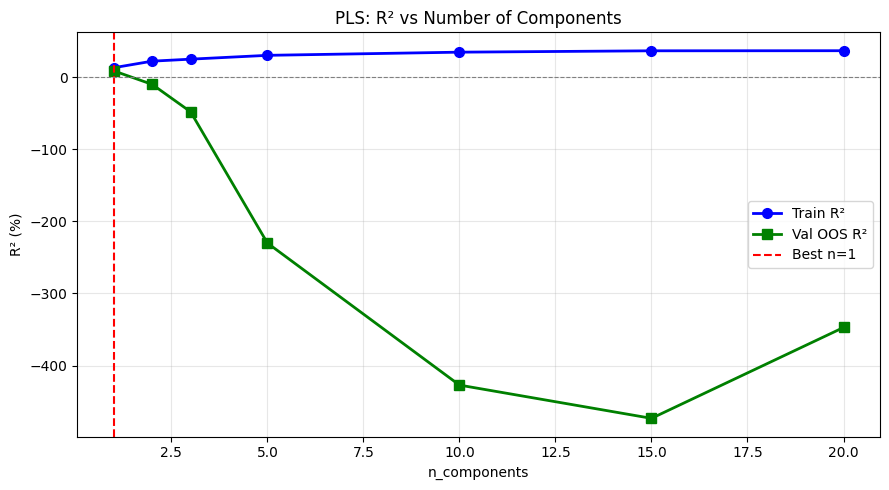

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ns = [r['n_components'] for r in grid_results]
ax.plot(ns, [r['r2_train']*100 for r in grid_results], 'b-o', label='Train R²', linewidth=2, markersize=7)
ax.plot(ns, [r['oos_r2_val']*100 for r in grid_results], 'g-s', label='Val OOS R²', linewidth=2, markersize=7)
ax.axvline(x=best['n_components'], color='red', linestyle='--', label=f"Best n={best['n_components']}")
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('n_components')
ax.set_ylabel('R² (%)')
ax.set_title('PLS: R² vs Number of Components')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — Final Evaluation on All Splits

In [7]:
m = best['model']
preds = {'train': m.predict(X_tr).ravel(), 'val': m.predict(X_va).ravel(), 'test': m.predict(X_te).ravel()}
metrics = evaluate_splits(y_train, preds['train'], y_val, preds['val'], y_test, preds['test'], y_train_mean)

print('PLS — BEST MODEL EVALUATION')
print('=' * 50)
print(f"  n_components : {best['n_components']}")
print(f"  Features     : {len(feature_cols)} → {best['n_components']} components")
print()
print(f"  Train R²     : {metrics['r2_train']*100:+.4f}%")
print(f"  Val R²       : {metrics['r2_val']*100:+.4f}%")
print(f"  Test R²      : {metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val   : {metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test  : {metrics['oos_r2_test']*100:+.4f}%")
print('=' * 50)

PLS — BEST MODEL EVALUATION
  n_components : 1
  Features     : 209 → 1 components

  Train R²     : +13.1977%
  Val R²       : +7.1784%
  Test R²      : -7650.0551%

  OOS R² Val   : +8.8071%
  OOS R² Test  : -7606.8353%


## Step 5 — Component Loadings Analysis

Each loading shows how strongly an original feature contributes to a component.
Large absolute loading = the feature is important for that component.

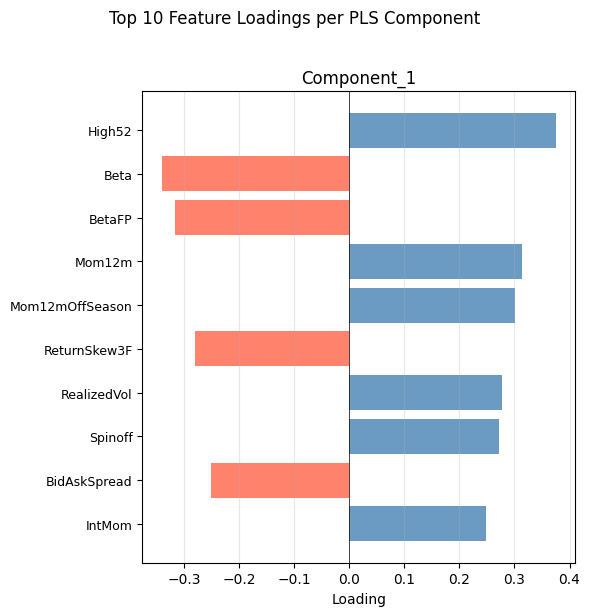

In [8]:
n_show = min(3, best['n_components'])
loadings_df = pd.DataFrame(
    m.x_loadings_,
    index=feature_cols,
    columns=[f'Component_{i+1}' for i in range(best['n_components'])],
)

top_n = 10
fig, axes = plt.subplots(1, n_show, figsize=(6 * n_show, 6))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    col  = f'Component_{i+1}'
    top  = loadings_df[col].abs().nlargest(top_n)
    vals = loadings_df.loc[top.index, col]
    colors = ['steelblue' if v > 0 else 'tomato' for v in vals]
    ax.barh(range(top_n), vals.values, color=colors, alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(vals.index, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Loading')
    ax.set_title(col)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Top {top_n} Feature Loadings per PLS Component', y=1.02)
plt.tight_layout()
plt.show()

## Step 6 — Portfolio Formation & Sharpe Ratio

PLS LONG-SHORT PORTFOLIO
  Months        : 552
  Mean monthly  : 3.8368%
  Std monthly   : 6.9909%
  Sharpe (ann.) : 1.9012


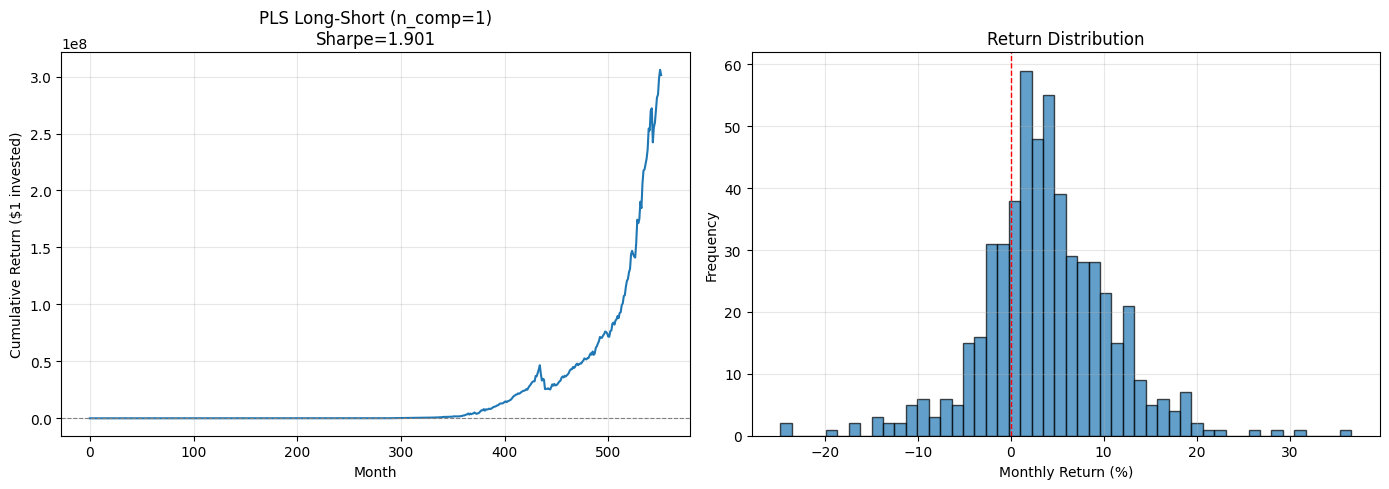

In [9]:
test_df = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()
test_df['predicted_ret'] = preds['test']
test_df = test_df.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

port_returns, comp_df = form_long_short_portfolio(
    test_df, CONFIG['DATE_COL'], 'predicted_ret', 'actual_ret', CONFIG['N_DECILES']
)
port_stats = portfolio_summary(port_returns)

print('PLS LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months        : {port_stats['n_periods']}")
print(f"  Mean monthly  : {port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly   : {port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.) : {port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cumulative = (1 + port_returns).cumprod()
axes[0].plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set(xlabel='Month', ylabel='Cumulative Return ($1 invested)',
            title=f'PLS Long-Short (n_comp={best["n_components"]})\nSharpe={port_stats["sharpe_annualized"]:.3f}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(port_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set(xlabel='Monthly Return (%)', ylabel='Frequency', title='Return Distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — Save Results

In [10]:
if CONFIG['SAVE_RESULTS']:
    summary = build_run_summary(
        model_name='PLS', description='Partial Least Squares Regression',
        tuning_params=f"n_components={best['n_components']}, max_iter={CONFIG['MAX_ITER']}",
        metrics=metrics, portfolio_stats=port_stats, split_info=split_info,
        n_features=len(feature_cols), fill_value=CONFIG['MISSING_FILL_VALUE'],
        standardized=CONFIG['STANDARDIZE'], notebook='pls_regression',
    )
    print(save_run_summary(summary, CONFIG['OUTPUT_DIR'], 'pls_summary.csv'))
    print(save_portfolio_compositions(comp_df, CONFIG['OUTPUT_DIR'], 'pls_portfolios.csv'))
else:
    print('SAVE_RESULTS = False — skipping.')

results/pls_summary.csv
results/pls_portfolios.csv
